Import Libraries

In [2]:
import pandas as pd
import numpy as np


Load Dataset

In [3]:
df = pd.read_csv("telco.csv")


Basic Inspection

In [4]:
df.shape


(7043, 22)

In [5]:
df.columns


Index(['Unnamed: 0', 'customerID', 'gender', 'SeniorCitizen', 'Partner',
       'Dependents', 'tenure', 'PhoneService', 'MultipleLines',
       'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges',
       'Churn'],
      dtype='object')

In [6]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 22 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   Unnamed: 0        7043 non-null   int64  
 1   customerID        7043 non-null   object 
 2   gender            7043 non-null   object 
 3   SeniorCitizen     7043 non-null   object 
 4   Partner           7043 non-null   object 
 5   Dependents        7043 non-null   object 
 6   tenure            7043 non-null   int64  
 7   PhoneService      7043 non-null   object 
 8   MultipleLines     7043 non-null   object 
 9   InternetService   7043 non-null   object 
 10  OnlineSecurity    7043 non-null   object 
 11  OnlineBackup      7043 non-null   object 
 12  DeviceProtection  7043 non-null   object 
 13  TechSupport       7043 non-null   object 
 14  StreamingTV       7043 non-null   object 
 15  StreamingMovies   7043 non-null   object 
 16  Contract          7043 non-null   object 


Clean Column Names

In [7]:
df.columns = df.columns.str.strip()


Drop Irrelevant Columns

In [8]:
df.drop(columns=['Unnamed: 0', 'customerID'], inplace=True)


Fix TotalCharges

In [10]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


Target Variable (IMPORTANT FIX)

In [11]:
df['Churn'].value_counts()


Churn
Stayed     5174
Churned    1869
Name: count, dtype: int64

Correct Mapping

In [12]:
df['Churn'] = df['Churn'].map({
    'Stayed': 0,
    'Churned': 1
})


In [13]:
df['Churn'].isna().sum()


np.int64(0)

Visualization

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns


Churn distribution

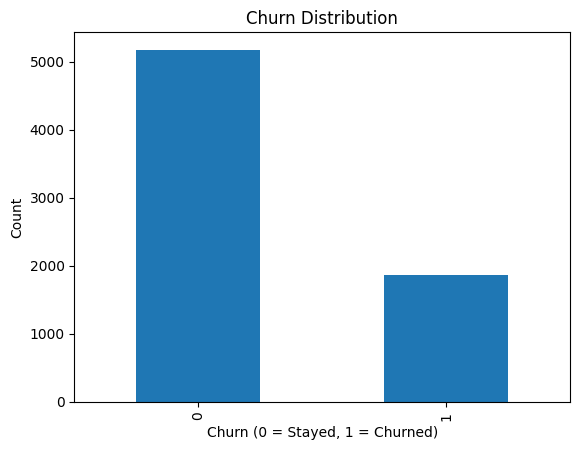

In [15]:
df['Churn'].value_counts().plot(kind='bar')
plt.title("Churn Distribution")
plt.xlabel("Churn (0 = Stayed, 1 = Churned)")
plt.ylabel("Count")
plt.show()


Tenure vs Churn

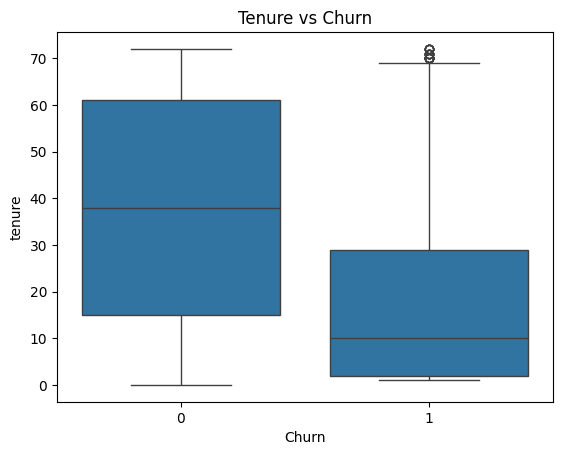

In [16]:
sns.boxplot(x='Churn', y='tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()


MonthlyCharges vs Churn

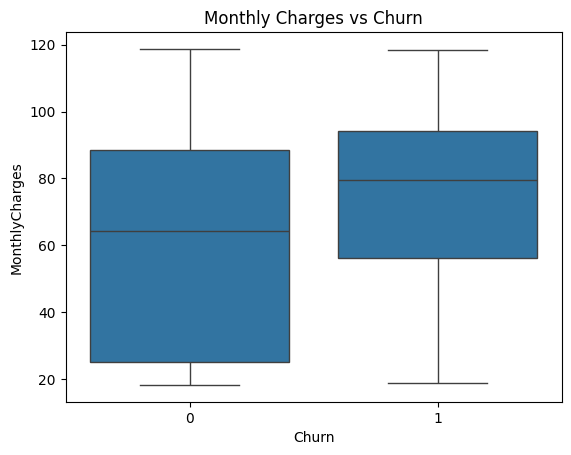

In [17]:
sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.title("Monthly Charges vs Churn")
plt.show()


Separate Features & Target

In [18]:
X = df.drop('Churn', axis=1)
y = df['Churn']


Contract vs Churn

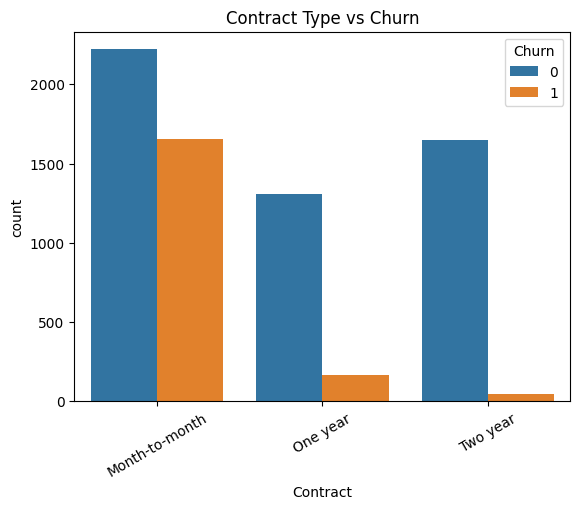

In [19]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.xticks(rotation=30)
plt.title("Contract Type vs Churn")
plt.show()


Correlation heatmap

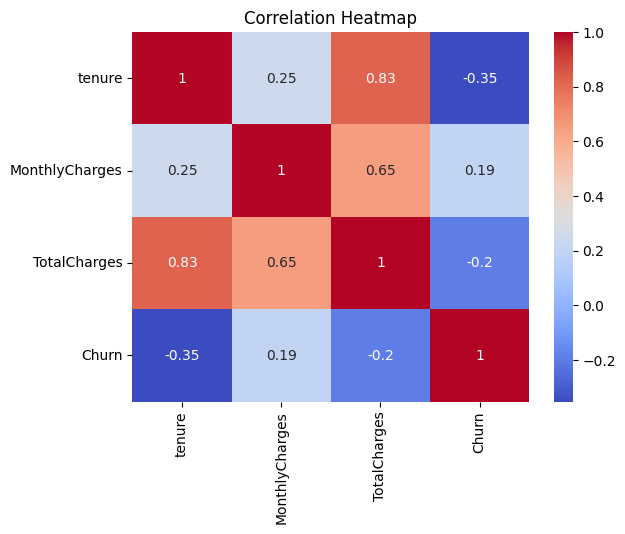

In [20]:
corr = df[['tenure', 'MonthlyCharges', 'TotalCharges', 'Churn']].corr()
sns.heatmap(corr, annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()


Train Test Split

In [21]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


Identify Columns

In [22]:
numerical_features = ['tenure', 'MonthlyCharges', 'TotalCharges']
categorical_features = [col for col in X.columns if col not in numerical_features]


Preprocessing Pipeline

In [24]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from imblearn.pipeline import Pipeline

numeric_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transformer = Pipeline([
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(drop='first', handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', numeric_transformer, numerical_features),
        ('cat', categorical_transformer, categorical_features)
    ]
)


Apply SMOTE (Correct Way)

In [25]:
from imblearn.pipeline import Pipeline
from imblearn.over_sampling import SMOTE


Logistic Regression Pipeline

In [26]:
from sklearn.linear_model import LogisticRegression

log_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', LogisticRegression(max_iter=1000))
])


Train Model

In [27]:
log_pipeline.fit(X_train, y_train)


,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Evaluation

In [28]:
from sklearn.metrics import classification_report, roc_auc_score

y_pred = log_pipeline.predict(X_test)
y_prob = log_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred))
roc_auc_score(y_test, y_prob)


              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.51      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



0.8398976982097186

XGBoost Pipeline

In [29]:
from xgboost import XGBClassifier

xgb_pipeline = Pipeline(steps=[
    ('preprocessing', preprocessor),
    ('smote', SMOTE(random_state=42)),
    ('model', XGBClassifier(
        eval_metric='logloss',
        random_state=42
    ))
])


Train XGBoost

In [30]:
xgb_pipeline.fit(X_train, y_train)


,steps,"[('preprocessing', ...), ('smote', ...), ...]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...), ('cat', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


Evaluate XGBoost

In [31]:
y_pred_xgb = xgb_pipeline.predict(X_test)
y_prob_xgb = xgb_pipeline.predict_proba(X_test)[:, 1]

print(classification_report(y_test, y_pred_xgb))
roc_auc_score(y_test, y_prob_xgb)


              precision    recall  f1-score   support

           0       0.86      0.85      0.85      1035
           1       0.59      0.61      0.60       374

    accuracy                           0.78      1409
   macro avg       0.72      0.73      0.73      1409
weighted avg       0.79      0.78      0.79      1409



0.8164419127334728

Save Pipeline

In [32]:
import joblib

joblib.dump(xgb_pipeline, "churn_prediction_pipeline.joblib")


['churn_prediction_pipeline.joblib']

Load & Test on New Customer

In [33]:
loaded_model = joblib.load("churn_prediction_pipeline.joblib")

sample_customer = pd.DataFrame([{
    'gender': 'Male',
    'SeniorCitizen': 'No',
    'Partner': 'No',
    'Dependents': 'No',
    'tenure': 2,
    'PhoneService': 'Yes',
    'MultipleLines': 'No',
    'InternetService': 'Fiber optic',
    'OnlineSecurity': 'No',
    'OnlineBackup': 'No',
    'DeviceProtection': 'No',
    'TechSupport': 'No',
    'StreamingTV': 'Yes',
    'StreamingMovies': 'Yes',
    'Contract': 'Month-to-month',
    'PaperlessBilling': 'Yes',
    'PaymentMethod': 'Electronic check',
    'MonthlyCharges': 95.0,
    'TotalCharges': 190.0
}])

prediction = loaded_model.predict(sample_customer)
probability = loaded_model.predict_proba(sample_customer)[0][1]

prediction, probability


(array([1]), np.float32(0.8930465))

In [34]:
if prediction[0] == 1:
    print(f"Customer is likely to CHURN (Probability: {probability:.2f})")
else:
    print(f"Customer is likely to STAY (Probability: {probability:.2f})")


Customer is likely to CHURN (Probability: 0.89)
